<a href="https://colab.research.google.com/github/AlbertPuentes/R1-A2-S5_DISE-O_SOLUCION/blob/main/R1_A2_S5_DISE%C3%91O_SOLUCION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2612 - loss: 2.0400 - val_accuracy: 0.2300 - val_loss: 1.8597 - learning_rate: 0.0010
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3825 - loss: 1.6983 - val_accuracy: 0.4000 - val_loss: 1.7313 - learning_rate: 0.0010
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4762 - loss: 1.4974 - val_accuracy: 0.5400 - val_loss: 1.6009 - learning_rate: 0.0010
Epoch 4/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5175 - loss: 1.3763 - val_accuracy: 0.5800 - val_loss: 1.4750 - learning_rate: 0.0010
Epoch 5/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6375 - loss: 1.2058 - val_accuracy: 0.6450 - val_loss: 1.3460 - learning_rate: 0.0010
Epoch 6/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6413 - loss: 1.1070 - val_accuracy: 0.6650 - val_loss: 1.2187 - learning_rate: 0.0010
Epoch 7/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6925 - loss: 1.0116 - val_ac

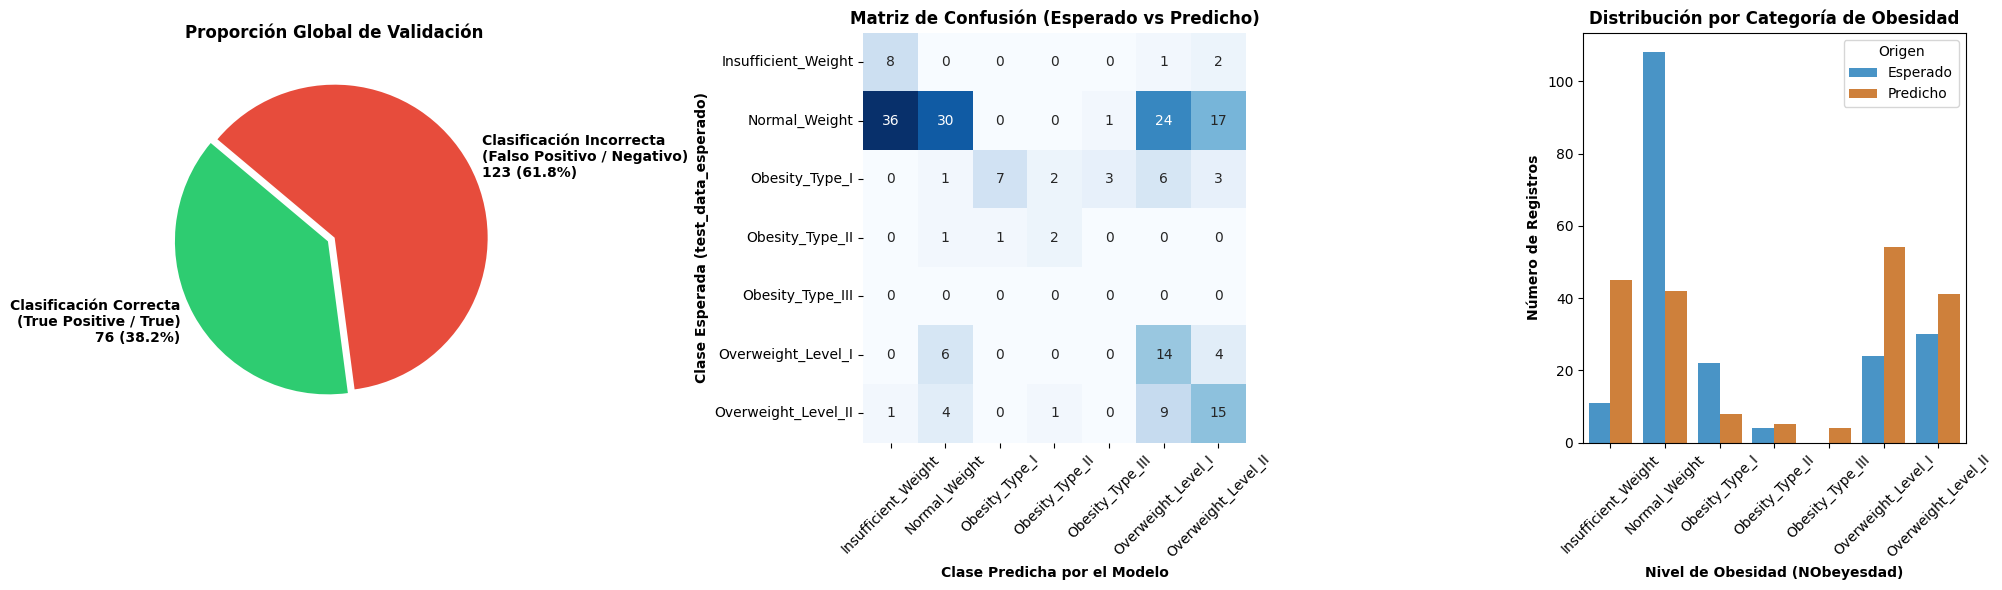

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARGA DE DATOS Y PREPROCESAMIENTO
# ==========================================

# Carga de archivos corregidos
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv', sep=';', engine='python') # Specify semicolon delimiter and engine

# Cargar test esperado si está disponible para evaluación final
try:
    test_esperado_df = pd.read_csv('test_data_esperado.csv') # Removed sep=';' - assuming comma-separated
    has_test_ground_truth = True
except Exception:
    has_test_ground_truth = False

# Identificación automática de la variable objetivo (última columna por defecto)
target_column = train_df.columns[-1]

# Separate features (X) and target (y)
X_train_raw = train_df.drop(columns=[target_column])
y_train_raw = train_df[target_column]

# Process test_df, dropping target if present (for prediction, it shouldn't be there)
if target_column in test_df.columns:
    X_test_raw = test_df.drop(columns=[target_column])
else:
    X_test_raw = test_df.copy() # Use .copy() to avoid SettingWithCopyWarning

# Identify categorical and numerical columns in features from X_train_raw
categorical_cols = X_train_raw.select_dtypes(include='object').columns
numerical_cols = X_train_raw.select_dtypes(exclude='object').columns

# Apply Label Encoding to the target variable
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_raw)
num_classes = len(label_encoder.classes_) # Number of unique classes for the output layer

if has_test_ground_truth:
    y_test_encoded = label_encoder.transform(test_esperado_df[target_column])

# Align columns of X_test_raw with X_train_raw
train_feature_names = X_train_raw.columns

# Add missing columns to X_test_raw and fill with appropriate defaults
missing_cols_in_test = set(train_feature_names) - set(X_test_raw.columns)
for col in missing_cols_in_test:
    if col in categorical_cols:
        X_test_raw[col] = 'Unknown' # Placeholder for unknown categories
    else:
        X_test_raw[col] = 0 # Fill numerical missing with 0

# Drop extra columns from X_test_raw if any
extra_cols_in_test = set(X_test_raw.columns) - set(train_feature_names)
if extra_cols_in_test:
    X_test_raw = X_test_raw.drop(columns=list(extra_cols_in_test))

# Reorder X_test_raw columns to match X_train_raw
X_test_raw = X_test_raw[train_feature_names]

# Apply One-Hot Encoding to categorical features
onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on training data and transform both train and test features
X_train_categorical_encoded = onehot_encoder.fit_transform(X_train_raw[categorical_cols])
X_test_categorical_encoded = onehot_encoder.transform(X_test_raw[categorical_cols])

# Convert encoded categorical features to DataFrame
# Ensure indices are reset to avoid alignment issues if original DFs had non-default indices
X_train_categorical_df = pd.DataFrame(X_train_categorical_encoded, columns=onehot_encoder.get_feature_names_out(categorical_cols), index=X_train_raw.index)
X_test_categorical_df = pd.DataFrame(X_test_categorical_encoded, columns=onehot_encoder.get_feature_names_out(categorical_cols), index=X_test_raw.index)

# Concatenate numerical and one-hot encoded categorical features
X_train_processed = pd.concat([X_train_raw[numerical_cols], X_train_categorical_df], axis=1)
X_test_processed = pd.concat([X_test_raw[numerical_cols], X_test_categorical_df], axis=1)

# ==========================================
# 2. DIVISIÓN DE DATOS Y ESCALADO
# ==========================================

# División en entrenamiento (80%) y validación (20%)
# Use the processed features and encoded target
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_processed, y_train_encoded, test_size=0.20, random_state=42
)

# Escalado y estandarización de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val_split)
X_test_scaled = scaler.transform(X_test_processed) # Scale the processed test data

# Assign to y_train, y_val, y_test for consistency with original code's variable names
y_train = y_train_split
y_val = y_val_split
if has_test_ground_truth:
    y_test = y_test_encoded # Already encoded above


# ==========================================
# 3. CONSTRUCCIÓN DEL MODELO TENSORFLOW
# ==========================================

input_shape = (X_train_scaled.shape[1],)

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Changed for multi-class classification
])

# Compilación del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', # Changed for multi-class classification
    metrics=['accuracy'] # Changed metrics for classification
)

# ==========================================
# 4. CONFIGURACIÓN DE CALLBACKS
# ==========================================

# Detener entrenamiento si la pérdida de validación deja de mejorar
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Reducir tasa de aprendizaje ante estancamiento
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# ==========================================
# 5. ENTRENAMIENTO DEL MODELO
# ==========================================

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ==========================================
# 6. EVALUACIÓN Y PREDICCIÓN
# ==========================================

# Evaluación en conjunto de validación
val_metrics = model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"\n--- Métricas en Validación ---")
print(f"Pérdida (Cross-entropy): {val_metrics[0]:.4f}")
print(f"Precisión:            {val_metrics[1]:.4f}")

# Evaluación en conjunto test_esperado (si está disponible)
if has_test_ground_truth:
    test_metrics = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f"\n--- Métricas en Test Esperado ---")
    print(f"Pérdida (Cross-entropy): {test_metrics[0]:.4f}")
    print(f"Precisión:            {test_metrics[1]:.4f}")


# Generación de predicciones finales
predictions_prob = model.predict(X_test_scaled)
predictions_encoded = np.argmax(predictions_prob, axis=1) # Get the class with highest probability

# Convert encoded predictions back to original labels
predictions_labels = label_encoder.inverse_transform(predictions_encoded)

# Guardar resultados predichos agregando las columnas de control
output_df = test_df.copy()
output_df['NObeyesdad_Predicho'] = predictions_labels

if has_test_ground_truth:
    output_df['NObeyesdad_Esperado'] = test_esperado_df[target_column].values
    output_df['Coincide'] = (output_df['NObeyesdad_Predicho'] == output_df['NObeyesdad_Esperado'])
    output_df['Estado_Validacion'] = np.where(
        output_df['Coincide'],
        'Clasificación Correcta (True Positive / True)',
        'Clasificación Incorrecta (Falso Positivo / Negativo)'
    )

output_df.to_csv('resultado_predicion.csv', index=False)
output_df.to_csv('predicciones_test_4.csv', index=False)
print("\nPredicciones guardadas exitosamente en 'resultado_predicion.csv' y 'predicciones_test_4.csv'")


# ==========================================
# 7. VISUALIZACIÓN Y COMPARACIÓN DE PREDICCIONES VS ESPERADO
# ==========================================

if has_test_ground_truth:
    y_true_labels = test_esperado_df[target_column].values
    coincidencias = (predictions_labels == y_true_labels)

    total_samples = len(coincidencias)
    aciertos = coincidencias.sum()
    errores = total_samples - aciertos

    print("\n" + "="*70)
    print("             RESUMEN COMPARATIVO DE VALIDACIÓN DE CLASES             ")
    print("="*70)
    print(f"Total de registros evaluados:                         {total_samples}")
    print(f"• Clasificación correcta (True Positive / True):       {aciertos:3d} ({(aciertos/total_samples)*100:.2f}%)")
    print(f"• Clasificación incorrecta (Falso Positivo / Negativo): {errores:3d} ({(errores/total_samples)*100:.2f}%)")
    print("="*70 + "\n")

    # Configuración del panel de gráficos (3 subgráficas)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # --- Gráfica 1: Proporción Global de Coincidencia (Pie Chart) ---
    labels_pie = [
        f'Clasificación Correcta\n(True Positive / True)\n{aciertos} ({(aciertos/total_samples):.1%})',
        f'Clasificación Incorrecta\n(Falso Positivo / Negativo)\n{errores} ({(errores/total_samples):.1%})'
    ]
    colors_pie = ['#2ecc71', '#e74c3c']
    axes[0].pie([aciertos, errores], labels=labels_pie, startangle=140, colors=colors_pie,
                explode=(0.05, 0), textprops={'fontsize': 10, 'weight': 'bold'})
    axes[0].set_title('Proporción Global de Validación', fontsize=12, fontweight='bold')

    # --- Gráfica 2: Matriz de Confusión (Heatmap) ---
    cm = confusion_matrix(y_true_labels, predictions_labels, labels=label_encoder.classes_)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[1], cbar=False)
    axes[1].set_title('Matriz de Confusión (Esperado vs Predicho)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Clase Predicha por el Modelo', fontsize=10, fontweight='bold')
    axes[1].set_ylabel('Clase Esperada (test_data_esperado)', fontsize=10, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)

    # --- Gráfica 3: Comparación de Frecuencias por Categoría ---
    df_compare = pd.DataFrame({
        'Esperado': y_true_labels,
        'Predicho': predictions_labels
    })
    df_melted = pd.melt(df_compare, var_name='Origen', value_name='NObeyesdad') \
                  .groupby(['NObeyesdad', 'Origen']).size().reset_index(name='Cantidad')

    sns.barplot(data=df_melted, x='NObeyesdad', y='Cantidad', hue='Origen',
                ax=axes[2], palette=['#3498db', '#e67e22'])
    axes[2].set_title('Distribución por Categoría de Obesidad', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Nivel de Obesidad (NObeyesdad)', fontsize=10, fontweight='bold')
    axes[2].set_ylabel('Número de Registros', fontsize=10, fontweight='bold')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('graficas_validacion_coincidencia.png')
    plt.show()